***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.1 数据检查、可视化与初步质量控制](9_1_visualisation-inspection.ipynb)
    * 下一节： [9.3 连续谱基础成像](9_3_continuum_imaging.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.2 基础校准流程：从校准源到目标场

在一个最典型的连续谱处理工作流里，校准部分通常包含三层任务：

- 先用亮而平滑的 bandpass calibrator 解决频率响应；
- 再用相位校准源跟踪随时间变化的复增益；
- 最后把这些解转移到目标场，并检查改正后的残差是否接近噪声。

这一节对应第 8 章的实践化版本。重点不只是“能求出一个解”，而是理解为什么 bandpass 和 time gain 往往需要分开处理，以及 `applycal` 之后我们究竟该看什么。


***


In [2]:
def point_source_model_cube(flux, nsample, nant):
    model = np.full((nsample, nant, nant), flux + 0.0j, dtype=complex)
    for ant in range(nant):
        model[:, ant, ant] = 0.0
    return model


def solve_gains(data, model, n_iter=30, ref_ant=0, phase_only=False):
    nsample, nant, _ = data.shape
    gains = np.ones((nsample, nant), dtype=complex)
    eps = 1e-12

    for sample in range(nsample):
        gt = np.ones(nant, dtype=complex)
        for _ in range(n_iter):
            new = gt.copy()
            for p in range(nant):
                mask = np.ones(nant, dtype=bool)
                mask[p] = False
                num = np.sum(data[sample, p, mask] * gt[mask] * np.conj(model[sample, p, mask]))
                den = np.sum(
                    np.abs(gt[mask]) ** 2 * np.abs(model[sample, p, mask]) ** 2
                ) + eps
                new[p] = num / den

            if phase_only:
                new = new / np.maximum(np.abs(new), eps)

            ref = new[ref_ant]
            new = new / (ref / max(np.abs(ref), eps))
            gt = new
        gains[sample] = gt

    return gains


def apply_direction_independent_factors(model, factors, noise_std=0.0, rng=None):
    data = factors[:, :, None] * model * np.conj(factors[:, None, :])
    if noise_std > 0.0:
        if rng is None:
            rng = np.random.default_rng(0)
        data += noise_std * (
            rng.normal(size=data.shape) + 1j * rng.normal(size=data.shape)
        )
    for ant in range(data.shape[1]):
        data[:, ant, ant] = 0.0
    return data


def rms_complex(arr):
    return np.sqrt(np.mean(np.abs(arr) ** 2))


nant = 6
nchan = 48
ntime = 44
chans = np.linspace(-1.0, 1.0, nchan)
times_h = np.linspace(-3.0, 3.0, ntime)

bandpass_amp = 1.0 + 0.05 * chans[None, :] * np.linspace(-1.0, 1.0, nant)[:, None]
bandpass_phase = 0.14 * np.sin(np.pi * chans)[None, :] * np.linspace(0.3, 1.0, nant)[:, None]
true_bandpass = (bandpass_amp * np.exp(1j * bandpass_phase)).T

ant_phase = np.linspace(0.0, np.pi, nant, endpoint=False)
time_amp = 1.0 + 0.04 * np.sin(0.9 * times_h[:, None] + 0.4 * ant_phase[None, :])
time_phase = 0.22 * np.sin(1.6 * times_h[:, None] + ant_phase[None, :])
true_time_gains = time_amp * np.exp(1j * time_phase)

model_bandpass = point_source_model_cube(flux=8.0, nsample=nchan, nant=nant)
data_bandpass = apply_direction_independent_factors(
    model_bandpass,
    true_bandpass,
    noise_std=0.015,
    rng=RNG,
)
solved_bandpass = solve_gains(data_bandpass, model_bandpass, n_iter=35, ref_ant=0, phase_only=False)

model_phase = point_source_model_cube(flux=3.0, nsample=ntime, nant=nant)
data_phase = apply_direction_independent_factors(
    model_phase,
    true_time_gains,
    noise_std=0.018,
    rng=RNG,
)
solved_time = solve_gains(data_phase, model_phase, n_iter=35, ref_ant=0, phase_only=False)


### 9.2.1 先解 bandpass，再解时间增益

对多通道数据来说，把频率响应和时间响应混成一个单一问题通常并不高效。更常见的做法是：

- 用亮带通源在每个通道上独立求复增益，得到 per-channel bandpass；
- 再对已经 bandpass-correct 的数据沿频率平均，用相位校准源求时间变化的增益。

下面先看 bandpass 解，再看时间增益解。


天线 4 bandpass 振幅 RMS 误差 = 0.0011
天线 2 时间增益相位 RMS 误差 = 0.1582 rad


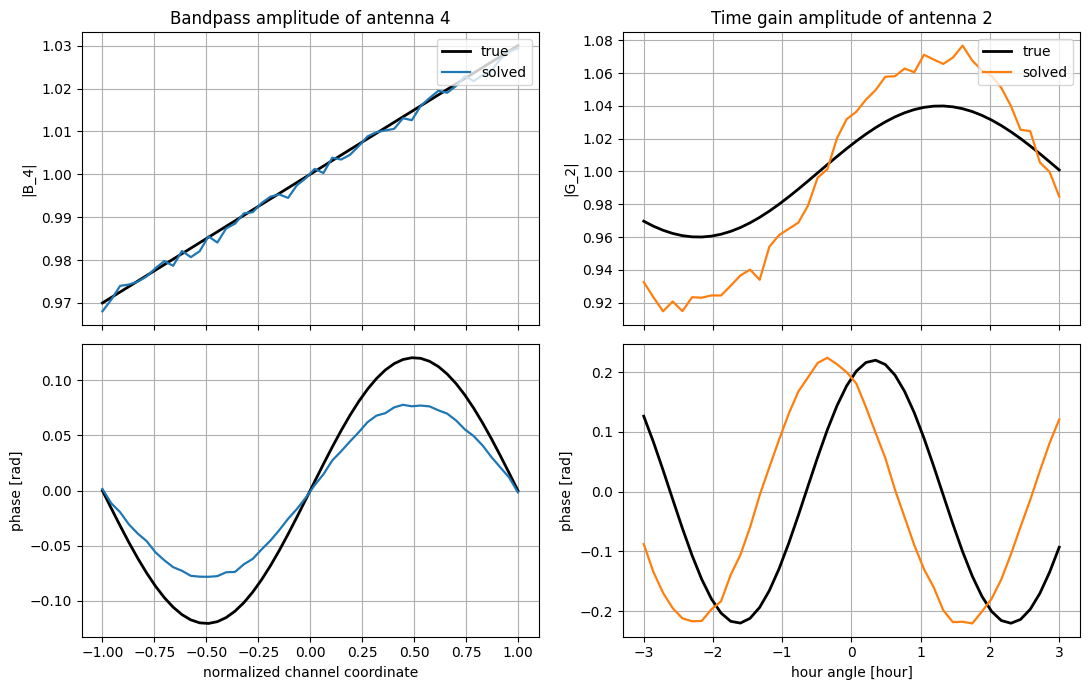

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex="col")

axes[0, 0].plot(chans, np.abs(true_bandpass[:, 4]), color="black", lw=2.0, label="true")
axes[0, 0].plot(chans, np.abs(solved_bandpass[:, 4]), color="tab:blue", lw=1.6, label="solved")
axes[0, 0].set_ylabel("|B_4|")
axes[0, 0].set_title("Bandpass amplitude of antenna 4")
axes[0, 0].legend(loc="upper right")

axes[1, 0].plot(chans, np.angle(true_bandpass[:, 4]), color="black", lw=2.0, label="true")
axes[1, 0].plot(chans, np.angle(solved_bandpass[:, 4]), color="tab:blue", lw=1.6, label="solved")
axes[1, 0].set_xlabel("normalized channel coordinate")
axes[1, 0].set_ylabel("phase [rad]")

axes[0, 1].plot(times_h, np.abs(true_time_gains[:, 2]), color="black", lw=2.0, label="true")
axes[0, 1].plot(times_h, np.abs(solved_time[:, 2]), color="tab:orange", lw=1.6, label="solved")
axes[0, 1].set_ylabel("|G_2|")
axes[0, 1].set_title("Time gain amplitude of antenna 2")
axes[0, 1].legend(loc="upper right")

axes[1, 1].plot(times_h, np.angle(true_time_gains[:, 2]), color="black", lw=2.0, label="true")
axes[1, 1].plot(times_h, np.angle(solved_time[:, 2]), color="tab:orange", lw=1.6, label="solved")
axes[1, 1].set_xlabel("hour angle [hour]")
axes[1, 1].set_ylabel("phase [rad]")

plt.tight_layout()

bp_amp_rms = np.sqrt(np.mean((np.abs(solved_bandpass[:, 4]) - np.abs(true_bandpass[:, 4])) ** 2))
time_phase_rms = np.sqrt(np.mean((np.angle(solved_time[:, 2] / true_time_gains[:, 2])) ** 2))
print(f"天线 4 bandpass 振幅 RMS 误差 = {bp_amp_rms:.4f}")
print(f"天线 2 时间增益相位 RMS 误差 = {time_phase_rms:.4f} rad")


在真实处理里，这一步大致对应 `bandpass` 和 `gaincal`。它们本质上都在求解天线基复增益，只是一个把“样本轴”看作频率，另一个把“样本轴”看作时间。


### 9.2.2 把 bandpass 与 time gain 一起应用到目标场

有了 bandpass 和时间增益后，我们就可以构造一个最简的 `applycal` 过程。这里的目标场采用一个相位中心点源加一个简单谱指数，只为了把注意力放在“校准前后差别”上。


目标场校准前 RMS 残差 = 0.2951
目标场校准后 RMS 残差 = 0.0889


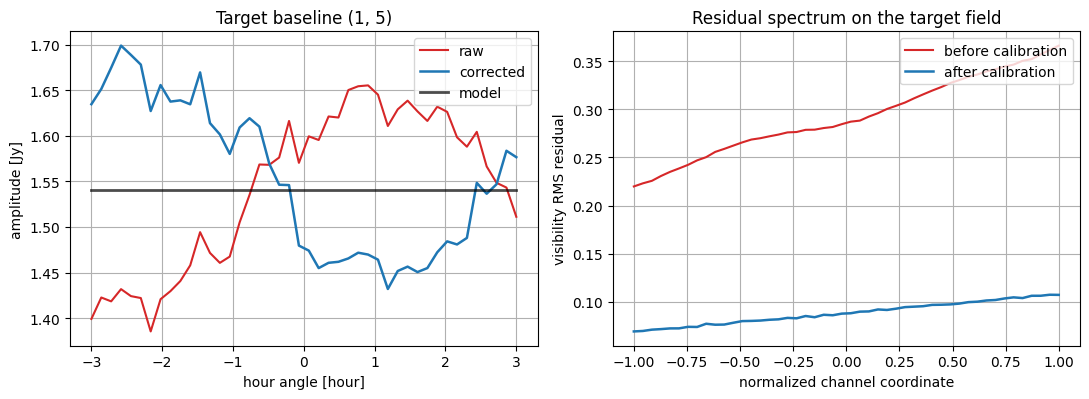

In [4]:
target_flux = 1.6 * (1.0 + 0.25 * chans)
target_model = np.zeros((ntime, nchan, nant, nant), dtype=complex)
for ti in range(ntime):
    for ci, flux in enumerate(target_flux):
        target_model[ti, ci] = point_source_model_cube(flux=flux, nsample=1, nant=nant)[0]

target_data = np.zeros_like(target_model, dtype=complex)
for ti in range(ntime):
    for ci in range(nchan):
        factors = true_time_gains[ti] * true_bandpass[ci]
        target_data[ti, ci] = (
            factors[:, None] * target_model[ti, ci] * np.conj(factors[None, :])
        )
target_data += 0.02 * (
    RNG.normal(size=target_data.shape) + 1j * RNG.normal(size=target_data.shape)
)

corrected_target = np.zeros_like(target_data, dtype=complex)
for ti in range(ntime):
    for ci in range(nchan):
        factors = solved_time[ti] * solved_bandpass[ci]
        corrected_target[ti, ci] = target_data[ti, ci] / (
            factors[:, None] * np.conj(factors[None, :]) + 1e-12
        )

raw_target_rms = rms_complex(target_data - target_model)
corrected_target_rms = rms_complex(corrected_target - target_model)
baseline = (1, 5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

axes[0].plot(
    times_h,
    np.abs(target_data[:, 20, baseline[0], baseline[1]]),
    color="tab:red",
    lw=1.5,
    label="raw",
)
axes[0].plot(
    times_h,
    np.abs(corrected_target[:, 20, baseline[0], baseline[1]]),
    color="tab:blue",
    lw=1.8,
    label="corrected",
)
axes[0].plot(
    times_h,
    np.abs(target_model[:, 20, baseline[0], baseline[1]]),
    color="black",
    lw=2.0,
    alpha=0.7,
    label="model",
)
axes[0].set_xlabel("hour angle [hour]")
axes[0].set_ylabel("amplitude [Jy]")
axes[0].set_title(f"Target baseline {baseline}")
axes[0].legend(loc="upper right")

rms_by_channel_raw = np.sqrt(np.mean(np.abs(target_data - target_model) ** 2, axis=(0, 2, 3)))
rms_by_channel_cor = np.sqrt(np.mean(np.abs(corrected_target - target_model) ** 2, axis=(0, 2, 3)))
axes[1].plot(chans, rms_by_channel_raw, color="tab:red", lw=1.5, label="before calibration")
axes[1].plot(chans, rms_by_channel_cor, color="tab:blue", lw=1.8, label="after calibration")
axes[1].set_xlabel("normalized channel coordinate")
axes[1].set_ylabel("visibility RMS residual")
axes[1].set_title("Residual spectrum on the target field")
axes[1].legend(loc="upper right")

plt.tight_layout()
print(f"目标场校准前 RMS 残差 = {raw_target_rms:.4f}")
print(f"目标场校准后 RMS 残差 = {corrected_target_rms:.4f}")


### 9.2.3 这一步在真实软件里对应什么？

一个最常见的连续谱校准主线可以概括为：

- `setjy`：设置通量校准源模型；
- `bandpass`：求解频率响应；
- `gaincal`：求解时间依赖的相位和振幅；
- `fluxscale`：把相对振幅解绑定到绝对通量标尺；
- `applycal`：把解应用到目标场；
- `plotms` / quick image：检查改正后数据是否真的改善。

这里的演示故意把它浓缩成了最小例子，但逻辑和真实处理链是一致的。完成这一步之后，下一节才有意义去做 dirty image、PSF 和 CLEAN；否则成像器面对的是一个仍然被系统误差污染的可见度集。
